Let's try doing the task 1 with multiple subjects 

In [ ]:
# Let's check how many dimensions i will use with PCA after loading the data

# step 1: import the necessary modules
import numpy as np
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# =======================================================================================
# CONFIGURATION - you will need to modify these to fit your own setup
# =======================================================================================
data_path = '/home/rbuu/psy3019/projet_final/data'      # path to your own data folder
subjects = ['003', '004', '005']                        # subjects to include
n_tr = 10                                               # number of TRs per trial
n_components = 150                                      # number of PCA dimensions
# =======================================================================================

X_train_list = []
X_test_list = []

for sub in subjects:
    # this loads the data from the subjects
    X_training = np.load(f'{data_path}/sub-{sub}/sub-{sub}_Resp_Training.npy', mmap_mode='r')
    X_test = np.load(f'{data_path}/sub-{sub}/sub-{sub}_Resp_Test_Mean.npy', mmap_mode='r')

    # This steps is crucial
    # First, it reshapes the arrays to have this format (labels,components????)
    # secondly, it averages out the fMRI data of the 10 seconds clip (the 10 TRs) to 1 single value.
    # Therefore, each clip is now associated to the mean activation
    X_training = X_training.T.reshape(480, n_tr, -1).mean(axis=1)
    X_test = X_test.T.reshape(60, n_tr, -1).mean(axis=1)

    # Since we are working with preprocessed data, the preprocessing steps did NOT
    # include normalization to a common brain space (e.g. MNI152). Each subject's
    # cortical mask contains a different number of voxels, as the preprocessing
    # retained each subject's individual cortical voxels rather than mapping them
    # to a shared template. Therefore, voxels cannot be directly compared across
    # subjects, and we apply PCA independently per subject to reduce each brain
    # to the same number of dimensions before concatenating.
    pca = PCA(n_components=n_components)
    X_training = pca.fit_transform(X_training)
    X_test = pca.transform(X_test)

    X_train_list.append(X_training)
    X_test_list.append(X_test)
    print(f'sub-{sub} done ✅ shape: {X_training.shape}')


sub-003 done ✅ shape: (480, 150)
sub-004 done ✅ shape: (480, 150)
sub-005 done ✅ shape: (480, 150)


In [43]:
# Concatenate all subjects
X_train_conc = np.concatenate(X_train_list, axis=0)  # (1440, 50)
X_test_conc = np.concatenate(X_test_list, axis=0)    # (180, 50)

print("X_train shape:", X_train_conc.shape)
print("X_test shape:", X_test_conc.shape)

# Load labels (same for all subjects)
trn = loadmat(f'{data_path}/AcrossGenre_Order_Trn.mat')
test = loadmat(f'{data_path}/AcrossGenre_Order_Test.mat')

y_train_single = trn['across_genre_rn_trn'].reshape(-1)  # (480,)
key = [k for k in test.keys() if not k.startswith('_')][0]
y_test_single = test[key][:, 0, :].flatten()             # (60,)

# Repeat labels for each subject
y_train = np.tile(y_train_single, len(subjects))  # (1440,)
y_test = np.tile(y_test_single, len(subjects))    # (180,)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1440, 150)
X_test shape: (180, 150)
y_train shape: (1440,)
y_test shape: (180,)


In [44]:
# Train SVM
clf = make_pipeline(
    StandardScaler(),
    LinearSVC()
)

clf.fit(X_train_conc, y_train)
print("Training done ✅")

Training done ✅


In [45]:
# Evaluate
accuracy = clf.score(X_test_conc, y_test)
print(f"Accuracy: {accuracy:.2%}")
print(f"Chance level: 10% (10 genres)")

Accuracy: 17.22%
Chance level: 10% (10 genres)


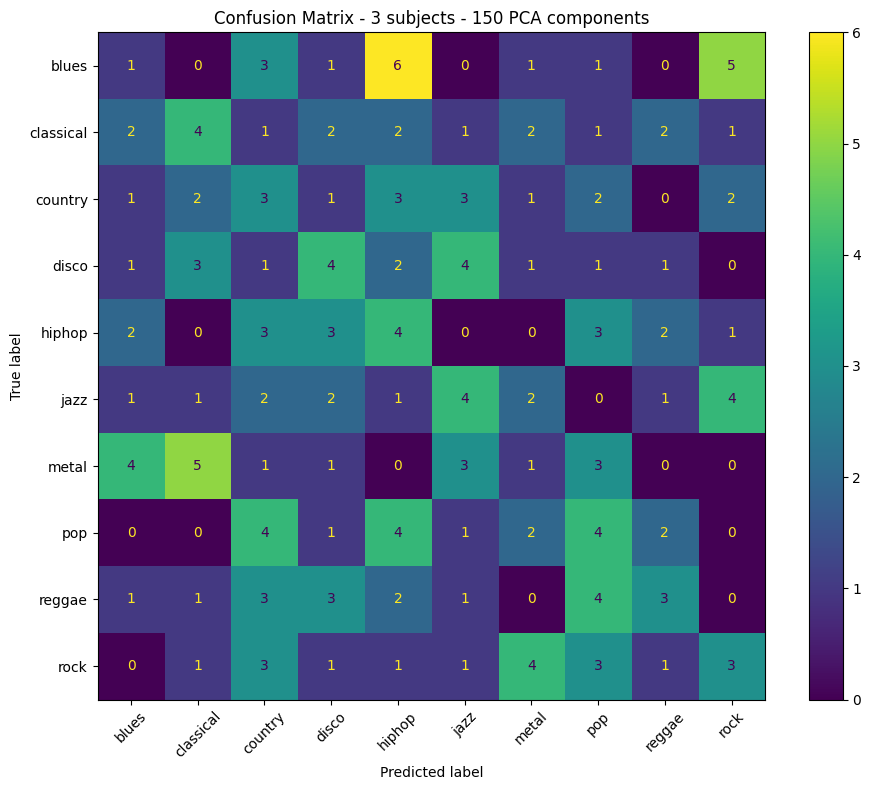

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

genre_map = {
    1: 'blues', 2: 'classical', 3: 'country', 4: 'disco',
    5: 'hiphop', 6: 'jazz', 7: 'metal', 8: 'pop',
    9: 'reggae', 10: 'rock'
}

y_pred = clf.predict(X_test_conc)

labels = sorted(np.unique(y_test))
label_names = [genre_map[l] for l in labels]

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f'Confusion Matrix - {len(subjects)} subjects - {n_components} PCA components')
plt.tight_layout()
plt.show()